In [12]:
import matplotlib.pyplot as plt

from rgfn import ReactionDataFactory

reaction_path = '../data/synflow/templates.txt'
fragment_path = '../data/synflow/fragments_all.txt'

data_factory = ReactionDataFactory(
    reaction_path=reaction_path,
    fragment_path=fragment_path
)

Using 148564 fragments, 105 reactions, and 197 anchored reactions


In [13]:
fragments = data_factory.get_fragments()
reactions = data_factory.get_reactions()
all_patterns = set()
for reaction in reactions:
    all_patterns.update(reaction.left_side_patterns)
len(all_patterns)

124

In [14]:
counts = []
for pattern in all_patterns:
    count = sum(fragment.rdkit_mol.HasSubstructMatch(pattern.rdkit_pattern) for fragment in fragments)
    counts.append(count)
sum(c == 0 for c in counts)

13

(array([13.,  0.,  0.,  0., 56., 13.,  6.,  6.,  3.,  0.,  0.,  1.,  4.,
         3.,  2.,  3.,  2.,  0.,  2.,  0.,  1.,  0.,  0.,  0.,  5.,  0.,
         2.,  0.,  1.,  1.]),
 array([-10000.        ,  -7762.16666667,  -5524.33333333,  -3286.5       ,
         -1048.66666667,   1189.16666667,   3427.        ,   5664.83333333,
          7902.66666667,  10140.5       ,  12378.33333333,  14616.16666667,
         16854.        ,  19091.83333333,  21329.66666667,  23567.5       ,
         25805.33333333,  28043.16666667,  30281.        ,  32518.83333333,
         34756.66666667,  36994.5       ,  39232.33333333,  41470.16666667,
         43708.        ,  45945.83333333,  48183.66666667,  50421.5       ,
         52659.33333333,  54897.16666667,  57135.        ]),
 <BarContainer object of 30 artists>)

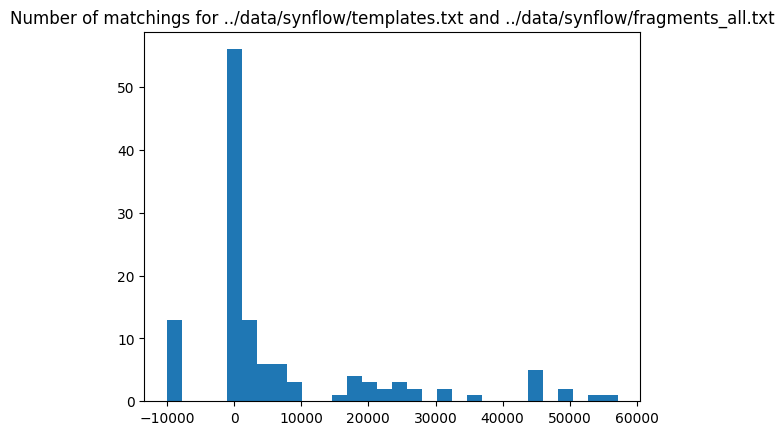

In [17]:
counts = [c if c > 0 else -10000 for c in counts]
plt.title(f'Number of matchings for {reaction_path} and {fragment_path}')
plt.hist(counts, bins=30)